# QuickCart Warehouse Inventory Stockout Risk
### Supervised ML Classification — Safe / At-Risk / Imminent

**The Unlox Academy — DA-DS-1**



## 1. Load the data


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')



### Gotcha #2 preview: the `reliability_score` `'N/A'`

In [20]:
dim_stores    = pd.read_csv(DATA + "dim_stores.csv")
dim_skus      = pd.read_csv(DATA + "dim_skus.csv")
dim_suppliers = pd.read_csv(
    DATA + "dim_suppliers.csv",
    na_values=['N/A', 'missing', '--', 'NA', 'null'],
    keep_default_na=True
)
dim_events    = pd.read_csv(DATA + "dim_events.csv")
fact          = pd.read_csv(DATA + "fact_inventory_daily.csv")

print("dim_stores:   ", dim_stores.shape)
print("dim_skus:     ", dim_skus.shape)
print("dim_suppliers:", dim_suppliers.shape)
print("dim_events:   ", dim_events.shape)
print("fact:         ", fact.shape)


dim_stores:    (12, 8)
dim_skus:      (60, 9)
dim_suppliers: (15, 6)
dim_events:    (30, 5)
fact:          (21600, 16)


### Sanity check against the locked numbers in the spec


In [21]:
assert len(dim_stores) == 12
assert len(dim_skus) == 60
assert len(dim_suppliers) == 15
assert len(dim_events) == 30
assert len(fact) == 21600
print("Row counts all match the spec ✅")

dist = fact['stockout_risk'].value_counts(normalize=True).mul(100).round(2)
print("\nTarget distribution:")
print(dist)


Row counts all match the spec ✅

Target distribution:
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


## 2. The two planted data-quality gotchas

**Gotcha 1 — inconsistent city casing.**

In [22]:
mismatches = dim_stores[dim_stores['city'] != dim_stores['city_display']]
print(f"{len(mismatches)} stores have a city/city_display casing mismatch:")
mismatches[['store_id', 'city', 'city_display']]


2 stores have a city/city_display casing mismatch:


,store_id,city,city_display
2,ST03,Bengaluru,BENGALURU
8,ST09,Hyderabad,hyderabad


In [23]:
# Fix: standardize city_display to match the clean 'city' key
dim_stores['city_display'] = dim_stores['city_display'].str.title()
dim_stores['city'] = dim_stores['city'].str.title()
print("Fixed. Unique cities:", dim_stores['city'].unique())


Fixed. Unique cities: ['Mumbai' 'Bengaluru' 'Delhi' 'Pune' 'Hyderabad' 'Chennai']


**Gotcha 2 — the `'N/A'` reliability score**

In [24]:
n_missing = dim_suppliers['reliability_score'].isna().sum()
print(f"{n_missing} suppliers have a missing (was 'N/A') reliability_score")
dim_suppliers[dim_suppliers['reliability_score'].isna()]


3 suppliers have a missing (was 'N/A') reliability_score


,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
5,SUP06,QuickBev Distributors,"Personal Care, Home Care",NaN,1,2.2
13,SUP14,Prime Personal Care,Staples,NaN,4,1.9
14,SUP15,Regional Produce Hub,Beverages,NaN,5,2.1


## 3. EDA — verify the "money-moment" signals from the spec


Imminent rate by festival week:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64
Spike factor: 2.45x


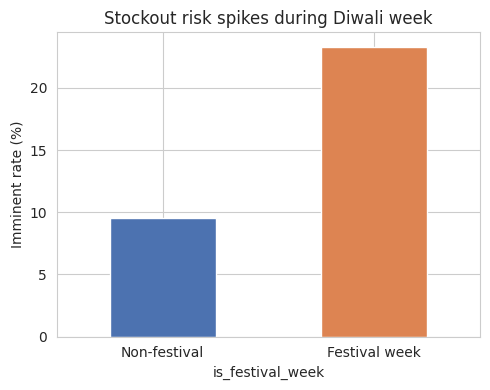

In [25]:
# Festival week effect
festival_imminent = fact.groupby('is_festival_week')['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print("Imminent rate by festival week:")
print(festival_imminent.round(2))
print(f"Spike factor: {festival_imminent['Y'] / festival_imminent['N']:.2f}x")

fig, ax = plt.subplots(figsize=(5, 4))
festival_imminent.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Imminent rate (%)')
ax.set_title('Stockout risk spikes during Diwali week')
ax.set_xticklabels(['Non-festival', 'Festival week'], rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Supplier reliability effect — need to join fact -> dim_suppliers first for this check
fact_sup = fact.merge(dim_suppliers[['supplier_id', 'reliability_score']], on='supplier_id', how='left')
fact_sup['reliability_score'] = fact_sup['reliability_score'].fillna(fact_sup['reliability_score'].median())

def reliability_bucket(x):
    if x < 0.75: return 'Low (<0.75)'
    elif x < 0.85: return 'Mid (0.75-0.85)'
    else: return 'High (>=0.85)'

fact_sup['reliability_bucket'] = fact_sup['reliability_score'].apply(reliability_bucket)
rel_imminent = fact_sup.groupby('reliability_bucket')['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print(rel_imminent.reindex(['Low (<0.75)', 'Mid (0.75-0.85)', 'High (>=0.85)']).round(2))


reliability_bucket
Low (<0.75)        13.07
Mid (0.75-0.85)     3.26
High (>=0.85)       3.82
Name: stockout_risk, dtype: float64


In [27]:
# Perishable effect
fact_sku = fact.merge(dim_skus[['sku_id', 'is_perishable']], on='sku_id', how='left')
perish_imminent = fact_sku.groupby('is_perishable')['stockout_risk'].apply(lambda s: (s == 'Imminent').mean() * 100)
print(perish_imminent.round(2))

# Missing lead_time_days_actual — by construction, only populated on reorder days
missing_lt = fact['lead_time_days_actual'].isna().sum()
print(f"\nlead_time_days_actual missing: {missing_lt} of {len(fact)} ({missing_lt/len(fact)*100:.1f}%)")


is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64

lead_time_days_actual missing: 19899 of 21600 (92.1%)


## 4. Join everything into one modeling table

In [28]:
df = fact.merge(dim_stores, on='store_id', how='left')
df = df.merge(dim_skus, on='sku_id', how='left', suffixes=('', '_sku'))
df = df.merge(dim_suppliers, on='supplier_id', how='left', suffixes=('', '_sup'))
df = df.merge(dim_events, on='date', how='left', suffixes=('', '_evt'))

df['date'] = pd.to_datetime(df['date'])
print("Joined modeling table shape:", df.shape)
df.head(3)


Joined modeling table shape: (21600, 40)


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id_sku,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


## 5. Feature engineering


In [29]:
df['reorder_gap'] = df['reorder_point'] - df['closing_stock']
df['days_of_cover_ratio'] = df['days_of_cover'] / df['lead_time_days_expected']

median_reliability = df['reliability_score'].median()
df['supplier_reliability_clean'] = df['reliability_score'].fillna(median_reliability)

# Sort so the rolling window is chronological within each store-SKU pair
df = df.sort_values(['store_id', 'sku_id', 'date'])
df['is_recent_reorder'] = (
    df.groupby(['store_id', 'sku_id'])['reorder_placed']
      .transform(lambda s: (s == 'Y').rolling(3, min_periods=1).max())
)

df['day_of_month'] = df['date'].dt.day
festival_start = pd.Timestamp('2026-10-22')
df['days_since_festival_start'] = (df['date'] - festival_start).dt.days

df[['reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean',
    'is_recent_reorder', 'day_of_month', 'days_since_festival_start']].describe()


,reorder_gap,days_of_cover_ratio,supplier_reliability_clean,is_recent_reorder,day_of_month,days_since_festival_start
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000
mean,-53.536347,4.696304,0.748333,0.228333,15.500000,-6.500000
std,104.712819,4.491873,0.096182,0.419768,8.655642,8.655642
min,-810.000000,0.000000,0.630000,0.000000,1.000000,-21.000000
25%,-78.500000,1.628000,0.700000,0.000000,8.000000,-14.000000
50%,-26.300000,3.143333,0.710000,0.000000,15.500000,-6.500000
75%,0.000000,6.480000,0.830000,0.000000,23.000000,1.000000
max,393.500000,134.850000,0.930000,1.000000,30.000000,8.000000


## 6. Train/test split — time-based, not random

In [30]:
train = df[df['date'] <= '2026-10-23'].copy()
test  = df[df['date']  > '2026-10-23'].copy()
print("Train:", train.shape, " | Test:", test.shape)
print("Train date range:", train['date'].min().date(), "to", train['date'].max().date())
print("Test date range: ", test['date'].min().date(), "to", test['date'].max().date())


Train: (16560, 46)  | Test: (5040, 46)
Train date range: 2026-10-01 to 2026-10-23
Test date range:  2026-10-24 to 2026-10-30


In [31]:
numeric_features = ['reorder_gap', 'days_of_cover_ratio', 'supplier_reliability_clean',
                     'is_recent_reorder', 'day_of_month', 'days_since_festival_start',
                     'sales_velocity_7d', 'unit_price_inr', 'shelf_life_days']
categorical_features = ['category', 'popularity_tier', 'store_size']

X_train = pd.get_dummies(train[numeric_features + categorical_features], columns=categorical_features).fillna(0)
X_test  = pd.get_dummies(test[numeric_features + categorical_features], columns=categorical_features).fillna(0)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)  # align columns in case a category is missing from one split

y_train = train['stockout_risk']
y_test  = test['stockout_risk']

print("Feature matrix:", X_train.shape)


Feature matrix: (16560, 23)


## 7. Models


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

majority_class = y_train.value_counts().idxmax()
baseline_acc = (y_test == majority_class).mean()
print(f"Baseline (always predict '{majority_class}') test accuracy: {baseline_acc:.3f}")


Baseline (always predict 'Safe') test accuracy: 0.623


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_logreg))


=== Logistic Regression ===
              precision    recall  f1-score   support

     At-Risk       0.84      0.67      0.74      1126
    Imminent       0.79      0.88      0.83       775
        Safe       0.94      0.98      0.96      3139

    accuracy                           0.90      5040
   macro avg       0.86      0.84      0.85      5040
weighted avg       0.89      0.90      0.89      5040



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

     At-Risk       0.85      0.80      0.83      1126
    Imminent       0.85      0.81      0.83       775
        Safe       0.96      1.00      0.98      3139

    accuracy                           0.92      5040
   macro avg       0.89      0.87      0.88      5040
weighted avg       0.92      0.92      0.92      5040



## 8. Evaluation — recall on Imminent matters most


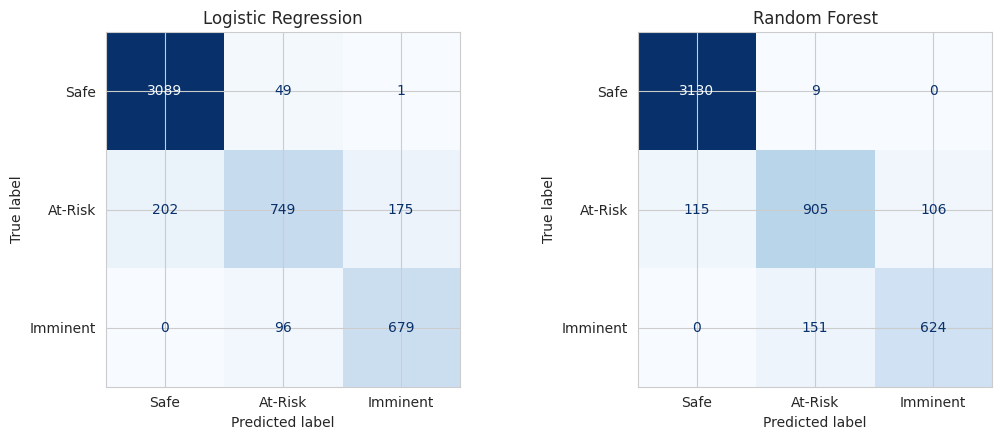

Logistic Regression — Imminent recall: 0.876
Random Forest — Imminent recall: 0.805


In [35]:
labels = ['Safe', 'At-Risk', 'Imminent']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(axes, [pred_logreg, pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

from sklearn.metrics import recall_score
for name, pred in [('Logistic Regression', pred_logreg), ('Random Forest', pred_rf)]:
    r = recall_score(y_test, pred, labels=['Imminent'], average='micro')
    print(f"{name} — Imminent recall: {r:.3f}")


Top 10 features (Random Forest):
days_of_cover_ratio           0.3404
reorder_gap                   0.3159
is_recent_reorder             0.0641
supplier_reliability_clean    0.0564
sales_velocity_7d             0.0545
days_since_festival_start     0.0283
day_of_month                  0.0276
shelf_life_days               0.0237
unit_price_inr                0.0232
category_Bakery               0.0073
dtype: float64


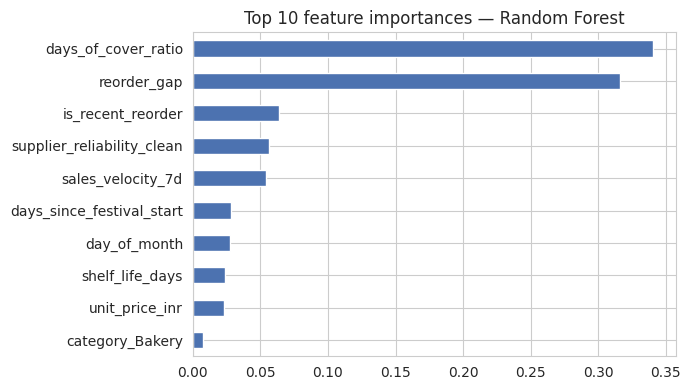

In [36]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 features (Random Forest):")
print(importances.head(10).round(4))

fig, ax = plt.subplots(figsize=(7, 4))
importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Top 10 feature importances — Random Forest')
plt.tight_layout()
plt.show()
